<a href="https://colab.research.google.com/github/JWasonga/Python-Data-Analysis-and-Visualization/blob/main/Labor_Force_participation_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LABOR FORCE PARTICIPATION DATA

##Data Loading

In [1]:
from google.colab import files
uploaded = files.upload ()

Saving PSID1976.csv to PSID1976.csv


## Importing all neccesary Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [3]:
df = pd.read_csv("PSID1976.csv")
df

,rownames,participation,hours,youngkids,oldkids,age,education,wage,repwage,hhours,...,hwage,fincome,tax,meducation,feducation,unemp,city,experience,college,hcollege
0,1,yes,1610,1,0,32,12,3.3540,2.65,2708,...,4.0288,16310,0.7215,12,7,5.0,no,14,no,no
1,2,yes,1656,0,2,30,12,1.3889,2.65,2310,...,8.4416,21800,0.6615,7,7,11.0,yes,5,no,no
2,3,yes,1980,1,3,35,12,4.5455,4.04,3072,...,3.5807,21040,0.6915,12,7,5.0,no,15,no,no
3,4,yes,456,0,3,34,12,1.0965,3.25,1920,...,3.5417,7300,0.7815,7,7,5.0,no,6,no,no
4,5,yes,1568,1,2,31,14,4.5918,3.60,2000,...,10.0000,27300,0.6215,12,14,9.5,yes,7,yes,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
748,749,no,0,0,2,40,13,0.0000,0.00,3020,...,9.2715,28200,0.6215,10,10,9.5,yes,5,yes,yes
749,750,no,0,2,3,31,12,0.0000,0.00,2056,...,4.8638,10000,0.7715,12,12,7.5,no,14,no,no
750,751,no,0,0,0,43,12,0.0000,0.00,2383,...,1.0898,9952,0.7515,10,3,7.5,no,4,no,no
751,752,no,0,0,0,60,12,0.0000,0.00,1705,...,12.4400,24984,0.6215,12,12,14.0,yes,15,no,no


##Checking Null values

In [4]:
df.isnull().sum()

,0
rownames,0
participation,0
hours,0
youngkids,0
oldkids,0
age,0
education,0
wage,0
repwage,0
hhours,0


In [5]:
df.head()

,rownames,participation,hours,youngkids,oldkids,age,education,wage,repwage,hhours,...,hwage,fincome,tax,meducation,feducation,unemp,city,experience,college,hcollege
0,1,yes,1610,1,0,32,12,3.3540,2.65,2708,...,4.0288,16310,0.7215,12,7,5.0,no,14,no,no
1,2,yes,1656,0,2,30,12,1.3889,2.65,2310,...,8.4416,21800,0.6615,7,7,11.0,yes,5,no,no
2,3,yes,1980,1,3,35,12,4.5455,4.04,3072,...,3.5807,21040,0.6915,12,7,5.0,no,15,no,no
3,4,yes,456,0,3,34,12,1.0965,3.25,1920,...,3.5417,7300,0.7815,7,7,5.0,no,6,no,no
4,5,yes,1568,1,2,31,14,4.5918,3.60,2000,...,10.0000,27300,0.6215,12,14,9.5,yes,7,yes,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   rownames       753 non-null    int64  
 1   participation  753 non-null    object 
 2   hours          753 non-null    int64  
 3   youngkids      753 non-null    int64  
 4   oldkids        753 non-null    int64  
 5   age            753 non-null    int64  
 6   education      753 non-null    int64  
 7   wage           753 non-null    float64
 8   repwage        753 non-null    float64
 9   hhours         753 non-null    int64  
 10  hage           753 non-null    int64  
 11  heducation     753 non-null    int64  
 12  hwage          753 non-null    float64
 13  fincome        753 non-null    int64  
 14  tax            753 non-null    float64
 15  meducation     753 non-null    int64  
 16  feducation     753 non-null    int64  
 17  unemp          753 non-null    float64
 18  city      

##Descriptive Statistics

In [6]:
df.describe()

,rownames,hours,youngkids,oldkids,age,education,wage,repwage,hhours,hage,heducation,hwage,fincome,tax,meducation,feducation,unemp,experience
count,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.00000
mean,377.000000,740.576361,0.237716,1.353254,42.537849,12.286853,2.374565,1.849734,2267.270916,45.120850,12.491368,7.482179,23080.594954,0.678863,9.250996,8.808765,8.623506,10.63081
std,217.516666,871.314216,0.523959,1.319874,8.072574,2.280246,3.241829,2.419887,595.566649,8.058793,3.020804,4.230559,12190.202026,0.083496,3.367468,3.572290,3.114934,8.06913
min,1.000000,0.000000,0.000000,0.000000,30.000000,5.000000,0.000000,0.000000,175.000000,30.000000,3.000000,0.412100,1500.000000,0.441500,0.000000,0.000000,3.000000,0.00000
25%,189.000000,0.000000,0.000000,0.000000,36.000000,12.000000,0.000000,0.000000,1928.000000,38.000000,11.000000,4.788300,15428.000000,0.621500,7.000000,7.000000,7.500000,4.00000
50%,377.000000,288.000000,0.000000,1.000000,43.000000,12.000000,1.625000,0.000000,2164.000000,46.000000,12.000000,6.975800,20880.000000,0.691500,10.000000,7.000000,7.500000,9.00000
75%,565.000000,1516.000000,0.000000,2.000000,49.000000,13.000000,3.787900,3.580000,2553.000000,52.000000,15.000000,9.166700,28200.000000,0.721500,12.000000,12.000000,11.000000,15.00000
max,753.000000,4950.000000,3.000000,8.000000,60.000000,17.000000,25.000000,9.980000,5010.000000,60.000000,17.000000,40.509000,96000.000000,0.941500,17.000000,17.000000,14.000000,45.00000


In [11]:
import numpy as np
import statsmodels.api as sm
from scipy.stats import norm

# Creating a copy to avoid modifying the original DataFrame
df_processed = df.copy()

# Converting 'participation' to numerical (0 for 'no', 1 for 'yes')
df_processed['participation_numeric'] = df_processed['participation'].apply(lambda x: 1 if x == 'yes' else 0)

# Converting other binary categorical columns to numerical
df_processed['city_numeric'] = df_processed['city'].apply(lambda x: 1 if x == 'yes' else 0)
df_processed['college_numeric'] = df_processed['college'].apply(lambda x: 1 if x == 'yes' else 0)
df_processed['hcollege_numeric'] = df_processed['hcollege'].apply(lambda x: 1 if x == 'yes' else 0)

pivot_with_binary = df_processed.pivot_table(
    index=['participation_numeric'],
    values=['age', 'education', 'city_numeric', 'college_numeric', 'hcollege_numeric'],
    aggfunc={'age': np.mean, 'education': np.mean, 'city_numeric': np.mean, 'college_numeric': np.mean, 'hcollege_numeric': np.mean}
)
display(pivot_with_binary)

print("Interpretation: For binary columns (converted to 0/1), the mean represents the proportion of 'yes' responses within each group.")

/tmp/ipykernel_1187/25110522.py:16: FutureWarning: The provided callable <function mean at 0x7a8168953b00> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_with_binary = df_processed.pivot_table(


,age,city_numeric,college_numeric,education,hcollege_numeric
participation_numeric,,,,,
0,43.283077,0.646154,0.209231,11.796923,0.363077
1,41.971963,0.640187,0.336449,12.658879,0.413551


Interpretation: For binary columns (converted to 0/1), the mean represents the proportion of 'yes' responses within each group.


##SECTION 1: Normality Test (Intensity variable -> Hours)

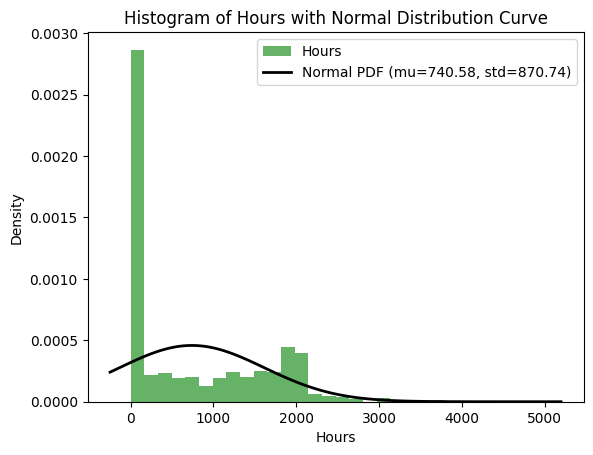

In [12]:
from scipy.stats import norm
import matplotlib.pyplot as plt

x = df['hours']

# Plotting the histogram
plt.hist(x, bins=30, density=True, alpha=0.6, color='g', label='Hours')

# Calculating mean and standard deviation for the normal distribution curve
mu, std = norm.fit(x)

# x-range for the normal distribution curve
xmin, xmax = plt.xlim()
x_plot = np.linspace(xmin, xmax, 100)

# Plotting the PDF of the normal distribution
p = norm.pdf(x_plot, mu, std)
plt.plot(x_plot, p, 'k', linewidth=2, label=f'Normal PDF (mu={mu:.2f}, std={std:.2f})')

plt.title('Histogram of Hours with Normal Distribution Curve')
plt.xlabel('Hours')
plt.ylabel('Density')
plt.legend()
plt.show()

In [13]:
import statsmodels.api as sm
from scipy.stats import norm

# Create a copy to avoid modifying the original DataFrame
df_processed = df.copy()

# Convert 'participation' to numerical (0 for 'no', 1 for 'yes')
df_processed['participation_numeric'] = df_processed['participation'].apply(lambda x: 1 if x == 'yes' else 0)

# Convert other binary categorical columns to numerical
df_processed['city_numeric'] = df_processed['city'].apply(lambda x: 1 if x == 'yes' else 0)
df_processed['college_numeric'] = df_processed['college'].apply(lambda x: 1 if x == 'yes' else 0)
df_processed['hcollege_numeric'] = df_processed['hcollege'].apply(lambda x: 1 if x == 'yes' else 0)

####The graph shows distribution of Hours worked and based on the histogram:
. **Many Zero Observations** - Indicate significant number of individuals who reported nt working any hours.

. **Right-Skewed Distribution** - The distribution is heavily skewed to the right.

. **Deviation from Normality** - The superimposed normal sitribution curve does not fit the histogram well, primarily due to the large number of zero values and strong right skew.

##SECTION 2: Estimating Participation and it's Intensity (Heckman Selection Model)

### Step 1: Selection Equation (Probit Model)

In [14]:
# Independent variables for the selection equation
selection_exog_vars = ['youngkids', 'oldkids', 'age', 'education', 'wage', 'fincome', 'tax', 'meducation', 'feducation', 'unemp', 'city_numeric', 'college_numeric', 'hcollege_numeric']
X_selection = df_processed[selection_exog_vars]
X_selection = sm.add_constant(X_selection) #Costant term

y_selection = df_processed['participation_numeric']

# Fit the Probit model
probit_model = sm.Probit(y_selection, X_selection)
probit_results = probit_model.fit()

print("Probit Model (Selection Equation) Summary:")
print(probit_results.summary())

# Calculate predicted probabilities of participation
predicted_probs = probit_results.predict(X_selection)

# Calculate the Inverse Mills Ratio (IMR)
# For those who participate (y_selection == 1), IMR = pdf(Z) / cdf(Z)
# For those who do not participate (y_selection == 0), IMR = -pdf(Z) / (1 - cdf(Z))

# Z is the linear predictor from the Probit model
Z = probit_results.fittedvalues * (norm.ppf(probit_results.fittedvalues) / probit_results.fittedvalues)

# Use the raw fitted values (probabilities) for IMR calculation
phi = norm.pdf(norm.ppf(predicted_probs)) # pdf of standard normal at probit's latent variable
Phi = predicted_probs                 # cdf of standard normal (which is the predicted probability itself)

# IMR for observed outcomes (those who participated)
imr = phi / Phi

# Store IMR in a new column in df_processed, only for participants
df_processed['IMR'] = imr

         Current function value: 0.000000
         Iterations: 35
Probit Model (Selection Equation) Summary:
                            Probit Regression Results                            
Dep. Variable:     participation_numeric   No. Observations:                  753
Model:                            Probit   Df Residuals:                      739
Method:                              MLE   Df Model:                           13
Date:                   Thu, 04 Jun 2026   Pseudo R-squ.:                   1.000
Time:                           05:21:31   Log-Likelihood:            -4.7003e-08
converged:                         False   LL-Null:                       -514.87
Covariance Type:               nonrobust   LLR p-value:                7.132e-212
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                5.0552   1.55e+05   3.26e-05      1.000   -3

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Step 2: Outcome Equation (OLS Model with IMR)

In [15]:
# Filter for participants (where 'hours' is not zero, assuming 0 hours means non-participation)
participants_df = df_processed[df_processed['hours'] > 0]

# Independent variables for the outcome equation, including IMR
outcome_exog_vars = ['age', 'education', 'experience', 'youngkids', 'oldkids', 'fincome', 'tax', 'unemp', 'city_numeric', 'college_numeric', 'hcollege_numeric', 'IMR']
X_outcome = participants_df[outcome_exog_vars]
X_outcome = sm.add_constant(X_outcome) # Add a constant term

y_outcome = participants_df['hours']

# Fit the OLS model
ols_model = sm.OLS(y_outcome, X_outcome)
ols_results = ols_model.fit()

print("\nOLS Model (Outcome Equation with IMR) Summary:")
print(ols_results.summary())


OLS Model (Outcome Equation with IMR) Summary:
                            OLS Regression Results                            
Dep. Variable:                  hours   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.169
Method:                 Least Squares   F-statistic:                     8.222
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           6.01e-14
Time:                        05:21:37   Log-Likelihood:                -3409.3
No. Observations:                 428   AIC:                             6845.
Df Residuals:                     415   BIC:                             6897.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

####The Analysis involved a two-step Heckman selection model to understand the factors influencing labor force participation (step 1 - Participation equation) and the intensity of work(hours) among participants (Step 2 - Quantity Equation). The model in overall achieved an R-squared of 0.192, meaning about 19.2% of the variance in hours worked is explained by the included variables. Significant predictors of hours worked included: Age(Negative effect), Education(Negative effect), Experience(Positive effect), Youngkids(Negative effect). The IMR term in OLS in insignificant, suggesting that correction for selection bias was effectively applied, and there is no statistical evidence of a self-selection problem.

## SECTION 3: Statistical Tests for OLS Model (Multicollinearity and Heteroscedasticity)

###1. Heteroscedasticity

In [16]:
# Heteroscedasticity Test (Breusch-Pagan)
from statsmodels.stats.api import het_breuschpagan

#  constant term for the test
if 'const' not in X_outcome.columns:
    X_outcome_bp = sm.add_constant(X_outcome.copy())
else:
    X_outcome_bp = X_outcome.copy()

# Calculate residuals from the OLS model
ols_residuals = ols_results.resid

#  Breusch-Pagan test
bp_test = het_breuschpagan(ols_residuals, X_outcome_bp)

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print("Breusch-Pagan Test for Heteroscedasticity:")
print(dict(zip(labels, bp_test)))

if bp_test[1] < 0.05:
    print("Conclusion: Significant heteroscedasticity detected (p-value < 0.05).")
else:
    print("Conclusion: No significant heteroscedasticity detected (p-value >= 0.05).")

Breusch-Pagan Test for Heteroscedasticity:
{'LM Statistic': np.float64(6.102580093037536), 'LM-Test p-value': np.float64(0.9108229141188685), 'F-Statistic': np.float64(0.5002343024458931), 'F-Test p-value': np.float64(0.9144944310982475)}
Conclusion: No significant heteroscedasticity detected (p-value >= 0.05).


###2. Multicollinearity

In [17]:
# Multicollinearity Test (Variance Inflation Factor - VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Exclude the IMR term from VIF calculation as it's a generated term and often high
# Also, exclude the constant term as VIF is calculated for independent variables
X_vif = X_outcome.drop(columns=['const', 'IMR'], errors='ignore')

vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("Variance Inflation Factor (VIF) for Multicollinearity:")
display(vif_data)

print("Interpretation: VIF values > 5 or > 10 typically indicate problematic multicollinearity.")

Variance Inflation Factor (VIF) for Multicollinearity:


,feature,VIF
0,age,48.214315
1,education,80.158403
2,experience,5.107129
3,youngkids,1.350168
4,oldkids,2.776378
5,fincome,10.433112
6,tax,76.500924
7,unemp,9.430732
8,city_numeric,3.152869
9,college_numeric,4.054510


Interpretation: VIF values > 5 or > 10 typically indicate problematic multicollinearity.


###3. Marginal Effects for Probit Model

In [18]:

marginal_effects = probit_results.get_margeff(at='overall', method='dydx')

print("Marginal Effects for Probit Model (Average Marginal Effects):")
print(marginal_effects.summary())

print("\nNote: Due to the 'Complete Separation' issue detected in the Probit model, these marginal effects should be interpreted with extreme caution, as the underlying model estimates are unreliable.")

Marginal Effects for Probit Model (Average Marginal Effects):
        Probit Marginal Effects         
Dep. Variable:     participation_numeric
Method:                             dydx
At:                              overall
                      dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
youngkids         -5.56e-10   9.76e-06  -5.69e-05      1.000   -1.91e-05    1.91e-05
oldkids          -4.281e-10   8.86e-06  -4.83e-05      1.000   -1.74e-05    1.74e-05
age              -1.107e-10   1.83e-06  -6.06e-05      1.000   -3.58e-06    3.58e-06
education        -1.134e-10   2.69e-06  -4.21e-05      1.000   -5.28e-06    5.28e-06
wage              4.479e-08      0.000      0.000      1.000      -0.001       0.001
fincome           -3.47e-14   7.82e-10  -4.44e-05      1.000   -1.53e-09    1.53e-09
tax               2.703e-09   7.61e-05   3.55e-05      1.000      -0.000       0.000
meducatio